# 04 - Friction

## Purpose

This notebook continues a series working toward an accurate, mathematically
proven servo control loop, built on empirical data. Notebook 00
characterized the measurement chain, notebook 01 the four bridge states and
the coast spin-down. This notebook measures the friction of the mechanism,
from the voltage that first moves it to the way it comes to rest.

The friction model is Coulomb plus viscous,

$$\tau_f = \tau_c\,\mathrm{sign}(\omega) + b_v\,\omega,$$

with $\tau_c$ the Coulomb torque and $b_v$ the viscous coefficient. Two
independent routes measure it in different units. In coast (route A) the
deceleration is $a + b\,v$ with $a = \tau_c / J$ and $b = b_v / J$. Under
drive at steady speed (route B) the motor current balances the friction,
$K_t\,i = \tau_c + b_v\,\omega$, so the steady-state current against speed
is a line $i = i_c + i_v\,\omega$ with $i_c = \tau_c / K_t$ and
$i_v = b_v / K_t$. Neither $J$ nor $K_t$ is known here, and the ratio
$\tau_c / b_v$ cancels both. It equals $a / b$ from route A and
$i_c / i_v$ from route B, and both are a speed, the speed at which viscous
friction equals Coulomb friction. Agreement of the two ratios is the test
this notebook is built around.

This notebook has three jobs:

1. Measure the breakaway duty and voltage per direction (section 5).
2. Measure the friction constants by both routes and test the ratio
   (sections 6 and 7).
3. Examine the approach to rest and the dependence of friction on position
   (section 8).

The dataset is three test series on a 2-cell lithium battery, described in
section 3.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01. The points this notebook depends on:

- A brushed DC motor driven by an H-bridge with 20 kHz center-aligned PWM
  under slow decay, so the OFF portion of every period is brake. **Duty**
  is the fraction of each period in the drive state.
- A gear train couples the motor to the output shaft, and a potentiometer
  on the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts and speed in wiper volts per second. The pot-derived speed
  carries a ripple of 20 to 30% with a period of 0.1 to 0.2 wiper V
  (notebook 01, section 6.1), so every speed estimate below states the
  window it averages over.
- A 33 mOhm shunt in the motor return path, amplified with gain 15.0, gives
  the motor current. The crest scan samples it at the center of the drive
  window. The amplifier output includes an offset, measured from the
  baseline segment of each recording and subtracted throughout.
- Both motor terminals are read through 20 kOhm / 10 kOhm dividers whose
  bottom legs return to a common bias node $V_B$ of about 0.62 V, so both
  terminals stay readable during coast and their difference reads the
  back-EMF free of the bias (notebook 01, sections 2 and 6.1). That
  difference is the direct speed signal route A uses.

Power is a 2-cell lithium battery, nominal 7.4 V, measured at the driven
terminal in section 5.2. The three series were captured in one session
without recharging, so the rail sags slowly from recording to recording.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the same as notebooks 00 and 01.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom, bottom leg returned to the terminal bias |
| Terminal bias $V_B$, nominal | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording, from the segment-0 baseline (section 3) |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |
| Winding resistance $R$ | 4.3 Ohm, input from notebook 03 (route A anchor) |

A drive-window current sample is settled for duty at or above 13.3% and a
drive-window voltage sample for duty at or above 17.5% (notebook 01,
section 2). The streamed `window_valid` flag encodes the current floor.
The whole breakaway ramp of section 5 lies below both floors, which is why
its current is shown and never fitted.

A terminal voltage $V_t$ reaches the ADC pin as $\text{tap} = V_t / 3 +
2 V_B / 3$, so $V_t = 3\,\text{tap} - 2 V_B$ with the measured $V_B$ of the
recording, and the terminal difference is bias-free, $v_A - v_B =
3\,(\text{tap}_A - \text{tap}_B)$ in ADC volts.

The winding resistance enters once, in section 5.3, to turn the breakaway
voltage into a model-derived current. It is an input from notebook 03 and
is listed here so that every constant of this notebook is in one place.

Two caveats carry over. The ADC reference is the design value, so every
voltage scales with the true VDD of this unit. The divider, shunt and gain
are design values with unmeasured tolerances.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import least_squares, curve_fit

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # terminal bias divider from VDD, top leg
BIAS_BOT_OHM = 100          # terminal bias divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor
R_WINDING_OHM = 4.3         # winding resistance, notebook 03 (route A anchor)

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3: tap = Vt/3 + 2/3 VB
V_TERM_PER_COUNT = V_ADC_PER_COUNT * DIV_RATIO             # terminal difference
VB_NOM_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS

def term_V(tap_counts, vb_counts):
    # Absolute terminal voltage from a tap reading: Vt = 3 tap - 2 VB.
    return (DIV_RATIO * tap_counts - (DIV_RATIO - 1) * vb_counts) * V_ADC_PER_COUNT

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal difference", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V * 1e3, "unit": "mV"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V / V_ADC_PER_COUNT, "unit": "counts"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": FLOOR_I_PCT, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": FLOOR_V_PCT, "unit": "% duty and above"},
    {"quantity": "winding resistance (input)", "value": R_WINDING_OHM, "unit": "Ohm"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal difference,2.4170,mV per count
"terminal bias, nominal",622.6415,mV
"terminal bias, nominal",772.8302,counts
motor current,1.6276,mA per count
"drive window settled, current",13.3333,% duty and above
"drive window settled, voltage",17.5000,% duty and above
winding resistance (input),4.3000,Ohm


## 3. Capture method

Three test series enter, all under slow decay on the same battery, all in
the repository under `notebooks/telemetry/sg90/`, one folder per
recording. Every recording starts with a one-second baseline segment with
the bridge disabled, which gives the current offset, the terminal bias and
the position noise floor.

- **Ramp** (`breakaway/`, five recordings). After the baseline, 200 ms
  drive steps at 1%, 2%, ... 12% duty, first forward (segments 1 to 12)
  then reverse (segments 13 to 24). The first milliseconds of every step
  carry residual motion from the repositioning move, and the 1% steps
  carry little else. Motion is therefore judged from the last 100 ms of
  each step, never from total travel.
- **Spin-down** (`bridge/`, five recordings, the spin-down sweep of
  notebook 01). For 20%, 30% and 40% duty in turn, an 80 ms drive step
  followed by 400 ms of coast, then a second drive step at the same duty
  followed by 400 ms of brake, forward then reverse, 24 segments. The
  coast segments are route A's data.
- **Grid** (`2s/`, ten recordings). 80 ms drive steps at 5% to 100% in 5%
  increments, forward then reverse, 40 segments. The steady state at the
  end of each step is route B's data. The steps do not settle within
  80 ms, which section 6.1 measures and corrects.

Before every drive step of every series the servo is repositioned at 15%
duty toward the far end of travel, so the step has room to run. The
mechanism can still be moving from that repositioning move when the step
begins, in the direction opposite to the step.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames. Section 4 re-verifies this from the data itself.

Each row is one 50 us sample, with segment number, commanded duty,
direction, tick counter, the firmware's validity flag, position, the crest-scan shunt
(`current_raw`), the trough-scan shunt (`current_trough`), and the
crest-scan terminals (`vmotor_a`, `vmotor_b`). The spin-down metadata
lists the schedule, from which the kind of every zero-duty segment (coast
or brake) follows.

The segment-0 baseline of every recording gives two per-recording
constants, the shunt amplifier's bias (mean of `current_raw`) and the
terminal bias $V_B$ (median of `vmotor_a`, cross-checked against
`vmotor_b`). The table summarizes both per series.


In [2]:
TELEMETRY = Path("telemetry/sg90")

def load_sweep(rec_dir, stem):
    df = pd.read_csv(rec_dir / f"{stem}.csv.gz")
    meta_name = "meta.json" if stem == "sweep" else f"{stem}.meta.json"
    meta = json.loads((rec_dir / meta_name).read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if stem == "spindown":
        # Segment k (k >= 1) is schedule entry (k - 1) mod len(schedule).
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def load_series(base, stem):
    recs = {}
    for d in sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
        recs[d.name] = load_sweep(d, stem)
    return recs

ramp = load_series(TELEMETRY / "breakaway", "sweep")
spin = load_series(TELEMETRY / "bridge", "spindown")
grid = load_series(TELEMETRY / "2s", "sweep")

rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    bias = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    first = next(iter(recs.values()))
    rows.append({
        "series": series,
        "recordings": len(recs),
        "segments per recording": first[0]["seg"].nunique(),
        "drive step [ms]": first[1]["window_ms"],
        "VB [counts], min": vb.min(), "VB [counts], max": vb.max(),
        "VB [V], mean": vb.mean() * V_ADC_PER_COUNT,
        "VB minus nominal [mV]": (vb.mean() * V_ADC_PER_COUNT - VB_NOM_V) * 1e3,
        "terminal B minus A at rest [counts], max": np.abs(vb_b - vb).max(),
        "shunt bias [counts], min": bias.min(), "shunt bias [counts], max": bias.max(),
    })
pd.DataFrame(rows).set_index("series").round(3).T


series,ramp,spin-down,grid
recordings,5.000,5.000,10.000
segments per recording,25.000,25.000,41.000
drive step [ms],200.000,80.000,80.000
"VB [counts], min",776.000,776.000,776.000
"VB [counts], max",776.000,776.000,777.000
"VB [V], mean",0.625,0.625,0.626
VB minus nominal [mV],2.554,2.554,3.279
"terminal B minus A at rest [counts], max",2.000,2.000,2.000
"shunt bias [counts], min",104.512,103.131,102.073
"shunt bias [counts], max",105.242,105.205,103.849


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every recording from the tick
column, which increments by one per sample within a segment.


In [3]:
rows = []
for series, recs in [("ramp", ramp), ("spin-down", spin), ("grid", grid)]:
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "series": series,
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
integ = pd.DataFrame(rows)
integ.groupby("series")[["samples", "segments", "missing_samples"]].agg(["min", "max"])


samples         segments     missing_samples    
              min     max      min max             min max
series                                                    
grid        84000   84000       41  41               0   0
ramp       116000  116000       25  25               0   0
spin-down  135200  135200       25  25               0   0

Every recording of every series has zero missing samples.

## 5. Breakaway

### 5.1 Motion onset per direction

For every ramp step the speed is the slope of a least-squares line through
the position of the last 100 ms of the 200 ms step, signed along the
commanded direction. The same slope over the first 100 ms shows the
residual motion from the repositioning move. The motion threshold is five
times the largest 100 ms slope found in the settled baselines of all ramp
and grid recordings (the first 200 ms of each baseline are dropped, since
the mechanism is still coming to rest from the initial move).


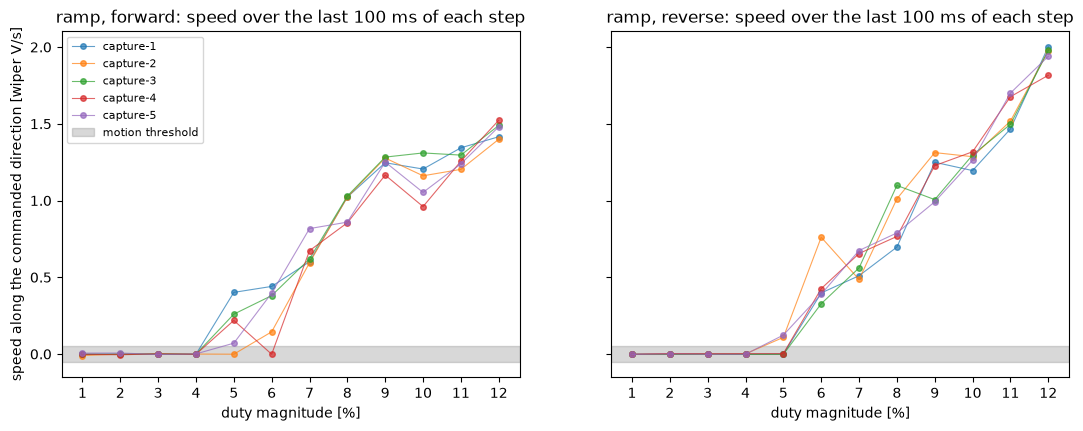

highest still [%]  lowest moving [%]  \
direction recording                                         
forward   capture-1                  4                  5   
          capture-2                  5                  6   
          capture-3                  4                  5   
          capture-4                  6                  5   
          capture-5                  4                  5   
reverse   capture-1                  5                  6   
          capture-2                  4                  5   
          capture-3                  5                  6   
          capture-4                  5                  6   
          capture-5                  4                  5   

                     all moving from [%]  speed at 5% [wiper V/s]  \
direction recording                                                 
forward   capture-1                    5                    0.402   
          capture-2                    6                   -0.001   
          capture-3                    5                    0.260   
          capture-4                    7                    0.219   
          capture-5                    5                    0.071   
reverse   capture-1                    6                   -0.001   
          capture-2                    5                    0.108   
          capture-3                    6                   -0.002   
          capture-4                    6                    0.002   
          capture-5                    5                    0.123   

                     speed at 6% [wiper V/s]  
direction recording                           
forward   capture-1                    0.440  
          capture-2                    0.145  
          capture-3                    0.381  
          capture-4                   -0.002  
          capture-5                    0.397  
reverse   capture-1                    0.398  
          capture-2                    0.761  
          capture-3                    0.328  
          capture-4                    0.426  
          capture-5                    0.390

In [4]:
WIN_100MS = 2000   # samples in the 100 ms judgment window

def baseline_slope_max(recs_list):
    # Largest |slope| over 100 ms windows of the settled baselines.
    worst = 0.0
    for recs in recs_list:
        for df, _ in recs.values():
            base = df[df["seg"] == 0]["pos"].to_numpy() * V_ADC_PER_COUNT
            base = base[len(base) // 5:]
            for k in range(0, len(base) - WIN_100MS, WIN_100MS):
                w = base[k:k + WIN_100MS]
                worst = max(worst, abs(np.polyfit(np.arange(WIN_100MS) / TICK_HZ, w, 1)[0]))
    return worst

MOTION_VPS = 5 * baseline_slope_max([ramp, grid])

def ramp_steps(df):
    out = []
    for seg_id, seg in df[df["seg"] > 0].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT
        t = np.arange(WIN_100MS) / TICK_HZ
        vb = seg["vb"].iloc[0]
        hi = "vmotor_a" if d > 0 else "vmotor_b"
        out.append({
            "mag_pct": int(round(abs(d))),
            "dir": int(s),
            "head_Vps": np.polyfit(t, p[:WIN_100MS], 1)[0] * s,
            "tail_Vps": np.polyfit(t, p[-WIN_100MS:], 1)[0] * s,
            "current_A": (seg["current_raw"].median() - seg["bias"].iloc[0]) * A_PER_COUNT,
            "valid_frac": seg["window_valid"].mean(),
            "driven_terminal_V": term_V(seg[hi].median(), vb),
        })
    return pd.DataFrame(out)

ramp_tab = pd.concat([ramp_steps(df).assign(recording=n) for n, (df, _) in ramp.items()])
ramp_tab["moving"] = ramp_tab["tail_Vps"] > MOTION_VPS

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, d, label in [(axes[0], 1, "forward"), (axes[1], -1, "reverse")]:
    for name, g in ramp_tab[ramp_tab["dir"] == d].groupby("recording"):
        ax.plot(g["mag_pct"], g["tail_Vps"], "-o", ms=4, lw=0.8, alpha=0.7, label=name)
    ax.axhspan(-MOTION_VPS, MOTION_VPS, color="grey", alpha=0.3, label="motion threshold")
    ax.set_xlabel("duty magnitude [%]")
    ax.set_title(f"ramp, {label}: speed over the last 100 ms of each step")
    ax.set_xticks(range(1, 13))
axes[0].set_ylabel("speed along the commanded direction [wiper V/s]")
axes[0].legend(fontsize=8)
plt.show()

rows = []
for (name, d), g in ramp_tab.groupby(["recording", "dir"]):
    rows.append({
        "recording": name,
        "direction": "forward" if d > 0 else "reverse",
        "highest still [%]": g[~g["moving"]]["mag_pct"].max(),
        "lowest moving [%]": g[g["moving"]]["mag_pct"].min(),
        "all moving from [%]": min(m for m in g["mag_pct"] if (g[g["mag_pct"] >= m]["moving"]).all()),
        "speed at 5% [wiper V/s]": g[g["mag_pct"] == 5]["tail_Vps"].iloc[0],
        "speed at 6% [wiper V/s]": g[g["mag_pct"] == 6]["tail_Vps"].iloc[0],
    })
onset = pd.DataFrame(rows).set_index(["direction", "recording"]).sort_index()
onset.round(3)


In [5]:
# Motion threshold, movers per grid point, and the residual motion of the
# first 100 ms against the last 100 ms, pooled over recordings.
movers = (ramp_tab[ramp_tab["mag_pct"] <= 8].groupby(["dir", "mag_pct"])["moving"]
          .sum().unstack(0).rename(columns={1: "forward movers of 5", -1: "reverse movers of 5"}))
speeds = (ramp_tab[ramp_tab["mag_pct"] <= 8].groupby(["dir", "mag_pct"])[["head_Vps", "tail_Vps"]]
          .mean().unstack(0))
speeds.columns = [f"{a} {'forward' if b > 0 else 'reverse'}" for a, b in speeds.columns]
out = pd.concat([movers, speeds], axis=1).round(3)
out.index.name = f"duty [%]  (threshold {MOTION_VPS:.3f} wiper V/s)"
out


,reverse movers of 5,forward movers of 5,head_Vps reverse,head_Vps forward,tail_Vps reverse,tail_Vps forward
duty [%] (threshold 0.050 wiper V/s),,,,,,
1,0,0,-0.206,-0.151,-0.002,-0.002
2,0,0,-0.000,-0.001,-0.000,-0.000
3,0,0,0.001,0.013,-0.001,-0.000
4,0,0,0.007,0.006,-0.000,-0.001
5,2,4,0.070,0.054,0.046,0.190
6,5,4,0.341,0.196,0.460,0.272
7,5,5,0.569,0.375,0.577,0.661
8,5,5,0.533,0.523,0.872,0.958


Findings:

- The threshold is 0.050 wiper V/s. Every step at 4% and below sits inside
  it in the last 100 ms, in both directions, in all five recordings. The
  1% steps show the residual motion of the repositioning move in their
  first 100 ms, 0.15 to 0.21 wiper V/s opposite to the command on average,
  and nothing in their last 100 ms.
- Forward, the 5% step moves in four of five recordings, the 6% step in
  four of five (a different recording sits still at 6% after moving at
  5%), and the 7% step in all five. Reverse, the 5% step moves in two of
  five and the 6% step in all five. The speed of a moving 5% step is 0.07
  to 0.40 wiper V/s and of a moving 6% step 0.15 to 0.76 wiper V/s, so a
  step either breaks away within its 200 ms or does not, and the outcome at
  5% and at forward 6% is a matter of chance from step to step.

The motion onset of this unit lies between 4% and 7% duty forward and
between 4% and 6% reverse, with 5% marginal in both directions.

### 5.2 Breakaway voltage

The ramp tops out at 12% duty, below the 17.5% floor, so the ramp has no
settled terminal sample by the floor rule. The supply rail comes from the
grid recordings, as the median driven terminal over the valid 20% to 30%
steps, the gentlest settled steps, in corrected terminal volts. The
ramp's own driven terminal at 8% to 12% forward is shown for
consistency. The breakaway voltage is the onset duty times the rail.


In [6]:
def rail_V(df, lo, hi):
    # Supply rail: median driven terminal over the valid drive steps in
    # the duty range, corrected for the recording's bias.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1)
           & (df["mag_pct"] >= lo) & (df["mag_pct"] <= hi)]
    driven = np.where(v["duty_pct"] > 0, v["vmotor_a"], v["vmotor_b"])
    return term_V(np.median(driven), df["vb"].iloc[0])

grid_rails = pd.Series({n: rail_V(df, 20, 30) for n, (df, _) in grid.items()})
RAIL_V = grid_rails.mean()
ramp_term = ramp_tab[(ramp_tab["dir"] > 0) & (ramp_tab["mag_pct"] >= 8)]["driven_terminal_V"]

rows = []
for label in ["forward", "reverse"]:
    o = onset.loc[label]
    still = int(o["highest still [%]"].max())
    low = int(o["lowest moving [%]"].min())
    high = int(o["all moving from [%]"].max())
    rows.append({
        "direction": label,
        "highest still in any recording [%]": still,
        "moving from [%], marginal": low,
        "moving from [%], every recording": high,
        "highest still in any recording [V]": still / 100 * RAIL_V,
        "breakaway low [V]": low / 100 * RAIL_V,
        "breakaway high [V]": high / 100 * RAIL_V,
    })
break_tab = pd.DataFrame(rows).set_index("direction")
break_tab.insert(0, "rail from grid [V]", RAIL_V)
break_tab.insert(1, "rail spread over recordings [V]", grid_rails.max() - grid_rails.min())
break_tab.insert(2, "ramp terminal 8 to 12% forward [V]", ramp_term.mean())
break_tab.round(3).T


direction,forward,reverse
rail from grid [V],7.347,7.347
rail spread over recordings [V],0.015,0.015
ramp terminal 8 to 12% forward [V],7.350,7.350
highest still in any recording [%],6.000,5.000
"moving from [%], marginal",5.000,5.000
"moving from [%], every recording",7.000,6.000
highest still in any recording [V],0.441,0.367
breakaway low [V],0.367,0.367
breakaway high [V],0.514,0.441


The rail is 7.35 V with a spread of 0.015 V across the ten grid
recordings, and the ramp's forward driven terminal at 8% to 12% reads the
same value to 0.01 V, so the ramp and the grid share one rail. The
breakaway voltage band is 0.37 to 0.51 V forward and 0.37 to 0.44 V
reverse. The highest duty that sat still in any recording is 6% forward
(0.44 V) and 5% reverse (0.37 V), and 0.29 V (4%) never moved in either
direction. The direction asymmetry rests on one forward recording that
sat still at 6% and cannot be resolved on a 1% grid with five recordings.

### 5.3 The unsettled current

The crest-scan current of every ramp step is shown below, bias
subtracted. The whole ramp lies under the 13.3% current floor, so these
readings are unsettled amplifier outputs and no quantity is fitted on
them. They rise with duty as expected of an amplifier that has settled
part way, and they are far below the current the winding carries.

The breakaway current is model-derived, as the breakaway voltage divided
by the winding resistance, which assumes the motor is at rest with no
back-EMF at the moment of breakaway. The resistance is the 4.3 Ohm input
from notebook 03 (section 2).


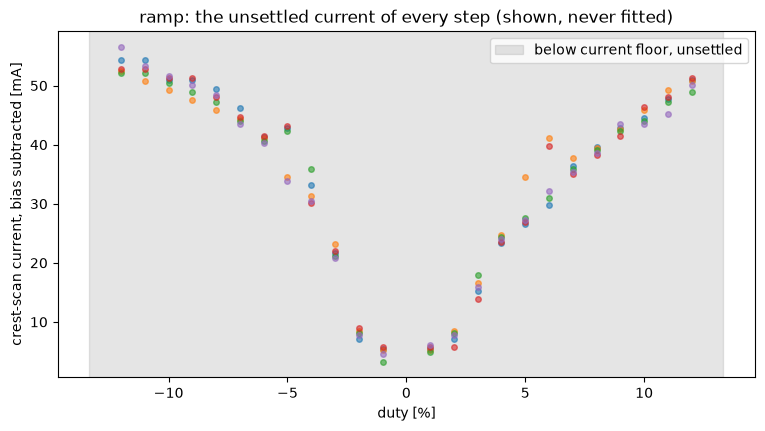

,value,spread,source
quantity,,,
unsettled crest current at 1% [mA],3.257,2.860,"ramp, both directions"
unsettled crest current at 12% [mA],48.830,7.743,"ramp, both directions"
winding resistance [Ohm],4.300,NaN,"notebook 03, route A anchor (input)"
"breakaway current, forward, low [A], model-derived",0.085,NaN,breakaway voltage / R
"breakaway current, forward, high [A], model-derived",0.120,NaN,breakaway voltage / R
"breakaway current, reverse, low [A], model-derived",0.085,NaN,breakaway voltage / R
"breakaway current, reverse, high [A], model-derived",0.103,NaN,breakaway voltage / R


In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, g in ramp_tab.groupby("recording"):
    ax.plot(g["mag_pct"] * g["dir"], g["current_A"] * 1e3, "o", ms=4, alpha=0.6)
ax.axvspan(-FLOOR_I_PCT, FLOOR_I_PCT, color="grey", alpha=0.2, label="below current floor, unsettled")
ax.set_xlabel("duty [%]")
ax.set_ylabel("crest-scan current, bias subtracted [mA]")
ax.set_title("ramp: the unsettled current of every step (shown, never fitted)")
ax.legend()
plt.show()

cur = ramp_tab.groupby("mag_pct")["current_A"].agg(["min", "max"]) * 1e3
rows = [
    {"quantity": "unsettled crest current at 1% [mA]", "value": cur.loc[1, "min"],
     "spread": cur.loc[1, "max"] - cur.loc[1, "min"], "source": "ramp, both directions"},
    {"quantity": "unsettled crest current at 12% [mA]", "value": cur.loc[12, "min"],
     "spread": cur.loc[12, "max"] - cur.loc[12, "min"], "source": "ramp, both directions"},
    {"quantity": "winding resistance [Ohm]", "value": R_WINDING_OHM,
     "spread": np.nan, "source": "notebook 03, route A anchor (input)"},
]
for label in ["forward", "reverse"]:
    rows.append({"quantity": f"breakaway current, {label}, low [A], model-derived",
                 "value": break_tab.loc[label, "breakaway low [V]"] / R_WINDING_OHM,
                 "spread": np.nan, "source": "breakaway voltage / R"})
    rows.append({"quantity": f"breakaway current, {label}, high [A], model-derived",
                 "value": break_tab.loc[label, "breakaway high [V]"] / R_WINDING_OHM,
                 "spread": np.nan, "source": "breakaway voltage / R"})
pd.DataFrame(rows).set_index("quantity").round(3)


With 4.3 Ohm the breakaway current is 0.085 to 0.12 A forward and
0.085 to 0.10 A reverse, model-derived. Section 6.1 finds the Coulomb
intercept of the drive current at 0.034 to 0.039 A, so the current at
breakaway exceeds the Coulomb current at speed by a factor of two or
more. *Hypothesis (not tested here): static friction exceeds kinetic
friction in this gear train, as is usual for lubricated metal and plastic
contacts. The test is a ramp with a settled current channel, which needs
a slower duty ramp above the floor or a different sampling scheme.*

## 6. Friction at speed

### 6.1 Route B, steady-state current against speed

For every grid step at or above the 15% grid point (the first above the
current floor) two quantities are needed, the steady speed and the steady
current. The reference estimate of each follows notebook 00 and uses the
last 60% of the step (48 ms). The speed is the slope of a line through
the position, and the current is the median of the crest-scan samples.

The steps do not settle in 80 ms. The current trace shows it without
ripple. After the first 10 ms it follows a single exponential toward a
floor, with a time constant of 17 to 21 ms in every step of every
recording. That is the mechanical time constant under drive, and 80 ms is
about four of them. Each step is therefore fitted with

$$i(t) = i_{ss} + A\,e^{-t/\tau},$$

which gives the steady current $i_{ss}$ by extrapolation and $\tau$ as a
quality flag. The speed uses the same mode. With $\tau$ fixed from the
current fit, the position over the same window is fitted with

$$p(t) = p_0 + v_{ss}\,t - (v_{ss} - v_0)\,\tau\,(1 - e^{-t/\tau}),$$

linear in $(p_0, v_{ss}, v_0)$, which averages the pot ripple over the
whole 70 ms window. Two quality flags follow from the fit, the remaining
transient in the reference window (how far the last-60% current sits
above the extrapolated steady value) and the residual acceleration at the
end of the step, $(v_{ss} - v_0)\,e^{-T/\tau} / \tau$ with $T$ the 70 ms
fit window, which is the acceleration the mechanism still had when the
step ended.

Route A's coast segments enter at speeds up to about 8.3 wiper V/s
(section 6.2). The like-for-like comparison of section 7 therefore fits
route B on steps whose steady speed lies at or below 8.5 wiper V/s (the
matched range). The fit is repeated on an extended range up to 10.5 and
on the full range, to show how the line depends on the range.


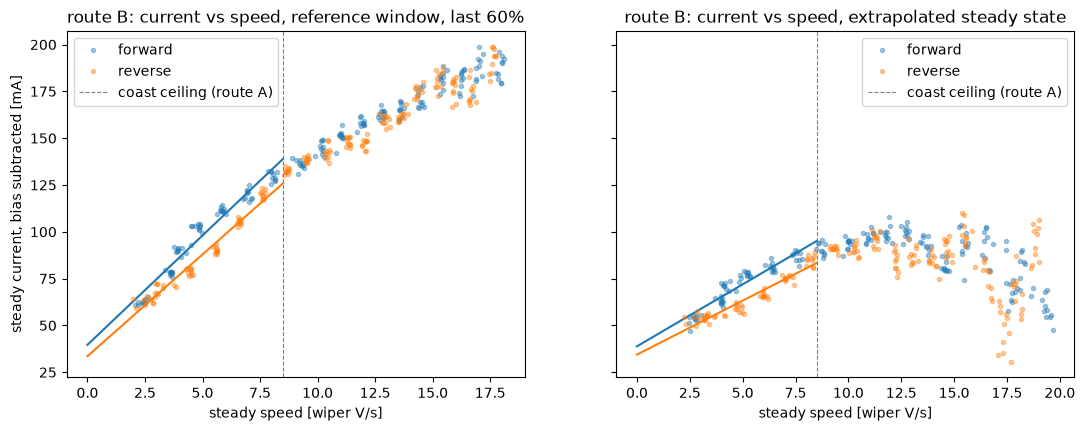

i_c [A]  \
method                     range             direction            
reference window, last 60% matched, <= 8.5   forward     0.0396   
                           extended, <= 10.5 forward     0.0466   
                           full              forward     0.0606   
                           matched, <= 8.5   reverse     0.0336   
                           extended, <= 10.5 reverse     0.0338   
                           full              reverse     0.0486   
extrapolated steady state  matched, <= 8.5   forward     0.0388   
                           extended, <= 10.5 forward     0.0447   
                           full              forward     0.0751   
                           matched, <= 8.5   reverse     0.0344   
                           extended, <= 10.5 reverse     0.0351   
                           full              reverse     0.0642   

                                                        i_v [A per wiper V/s]  \
method                     range             direction                          
reference window, last 60% matched, <= 8.5   forward                   0.0117   
                           extended, <= 10.5 forward                   0.0101   
                           full              forward                   0.0077   
                           matched, <= 8.5   reverse                   0.0109   
                           extended, <= 10.5 reverse                   0.0109   
                           full              reverse                   0.0084   
extrapolated steady state  matched, <= 8.5   forward                   0.0066   
                           extended, <= 10.5 forward                   0.0053   
                           full              forward                   0.0007   
                           matched, <= 8.5   reverse                   0.0058   
                           extended, <= 10.5 reverse                   0.0056   
                           full              reverse                   0.0012   

                                                        ratio [wiper V/s]  \
method                     range             direction                      
reference window, last 60% matched, <= 8.5   forward               3.3906   
                           extended, <= 10.5 forward               4.6212   
                           full              forward               7.8604   
                           matched, <= 8.5   reverse               3.0886   
                           extended, <= 10.5 reverse               3.1101   
                           full              reverse               5.7837   
extrapolated steady state  matched, <= 8.5   forward               5.8687   
                           extended, <= 10.5 forward               8.3891   
                           full              forward             113.3925   
                           matched, <= 8.5   reverse               5.9789   
                           extended, <= 10.5 reverse               6.2306   
                           full              reverse              54.0045   

                                                        ratio min  ratio max  \
method                     range             direction                         
reference window, last 60% matched, <= 8.5   forward       2.8424     3.9215   
                           extended, <= 10.5 forward       4.1046     5.1866   
                           full              forward       7.0887     8.5271   
                           matched, <= 8.5   reverse       2.1228     4.2863   
                           extended, <= 10.5 reverse       2.5740     4.0066   
                           full              reverse       5.1396     6.4330   
extrapolated steady state  matched, <= 8.5   forward       4.1449     7.7589   
                           extended, <= 10.5 forward       6.4889     9.6915   
                           full              forward      58.1528   237.9580   
                       

In [8]:
SKIP = 200        # first 10 ms of each step excluded from the fits
REF_FRAC = 0.4    # the reference window starts at 40% of the step (notebook 00)
V_MATCH = 8.5     # wiper V/s, the ceiling of route A's coast entry speeds
V_EXT = 10.5      # wiper V/s, the extended range

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

def grid_steps(df):
    out = []
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= 15)].groupby("seg"):
        d = seg["duty_pct"].iloc[0]
        s = np.sign(d)
        n = len(seg)
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT * s
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * A_PER_COUNT
        ok = seg["window_valid"].to_numpy() == 1
        ref = slice(int(n * REF_FRAC), n)
        v_ref = np.polyfit(np.arange(n - ref.start) / TICK_HZ, p[ref], 1)[0]
        i_ref = np.median(cur[ref][ok[ref]])
        t = np.arange(n - SKIP) / TICK_HZ
        c, tc = cur[SKIP:][ok[SKIP:]], t[ok[SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[SKIP:], rcond=None)[0]
        out.append({
            "mag_pct": int(round(abs(d))), "dir": int(s),
            "v_ref_Vps": v_ref, "i_ref_A": i_ref,
            "v_ss_Vps": v_ss, "i_ss_A": i_ss, "tau_ms": tau * 1e3,
            "transient_pct": (i_ref - i_ss) / i_ss * 100,
            "accel_end_Vps2": (v_ss - v0) / tau * np.exp(-t[-1] / tau),
            "pos_V": np.median(p[ref]) * s,
        })
    return pd.DataFrame(out)

grid_tab = pd.concat([grid_steps(df).assign(recording=n) for n, (df, _) in grid.items()])

def line_fit(tab, vcol, icol):
    k = np.polyfit(tab[vcol], tab[icol], 1)
    per = []
    for _, g in tab.groupby("recording"):
        kk = np.polyfit(g[vcol], g[icol], 1)
        per.append(kk[1] / kk[0])
    return {"i_c [A]": k[1], "i_v [A per wiper V/s]": k[0], "ratio [wiper V/s]": k[1] / k[0],
            "ratio min": min(per), "ratio max": max(per), "steps": len(tab)}

ranges = [(f"matched, <= {V_MATCH}", V_MATCH), (f"extended, <= {V_EXT}", V_EXT), ("full", np.inf)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
vv = np.linspace(0, V_MATCH, 50)
fits = []
for ax, vcol, icol, title in [(axes[0], "v_ref_Vps", "i_ref_A", "reference window, last 60%"),
                              (axes[1], "v_ss_Vps", "i_ss_A", "extrapolated steady state")]:
    for d, color, label in [(1, "tab:blue", "forward"), (-1, "tab:orange", "reverse")]:
        g = grid_tab[grid_tab["dir"] == d]
        ax.plot(g[vcol], g[icol] * 1e3, "o", ms=3, alpha=0.4, color=color, label=label)
        for rname, vmax in ranges:
            f = line_fit(g[g[vcol] <= vmax], vcol, icol)
            fits.append({"method": title, "range": rname, "direction": label, **f})
            if vmax == V_MATCH:
                ax.plot(vv, (f["i_c [A]"] + f["i_v [A per wiper V/s]"] * vv) * 1e3, "-",
                        color=color, lw=1.5)
    ax.axvline(V_MATCH, color="grey", lw=0.8, ls="--", label="coast ceiling (route A)")
    ax.set_xlabel("steady speed [wiper V/s]")
    ax.set_title(f"route B: current vs speed, {title}")
    ax.legend()
axes[0].set_ylabel("steady current, bias subtracted [mA]")
plt.show()

route_b = pd.DataFrame(fits).set_index(["method", "range", "direction"])
route_b.round(4)


In [9]:
# Quality flags by grid point, mean over recordings: time constant,
# remaining transient in the reference window, residual acceleration.
q = (grid_tab.groupby(["dir", "mag_pct"])[["v_ref_Vps", "v_ss_Vps", "i_ref_A", "i_ss_A",
                                           "tau_ms", "transient_pct", "accel_end_Vps2"]]
     .mean().unstack(0))
q.columns = [f"{a} {'fwd' if b > 0 else 'rev'}" for a, b in q.columns]
q[[c for c in q.columns if "fwd" in c] + [c for c in q.columns if "rev" in c]].round(3)


,v_ref_Vps fwd,v_ss_Vps fwd,i_ref_A fwd,i_ss_A fwd,tau_ms fwd,transient_pct fwd,accel_end_Vps2 fwd,v_ref_Vps rev,v_ss_Vps rev,i_ref_A rev,i_ss_A rev,tau_ms rev,transient_pct rev,accel_end_Vps2 rev
mag_pct,,,,,,,,,,,,,,
15,2.387,2.697,0.063,0.053,17.557,17.511,4.384,2.560,2.878,0.063,0.053,17.855,18.257,3.477
20,3.605,3.975,0.078,0.063,17.356,23.898,5.142,3.217,3.514,0.070,0.055,17.691,27.540,2.535
25,4.024,4.308,0.090,0.071,17.435,26.481,3.149,4.445,4.823,0.079,0.059,17.857,32.910,4.465
30,4.790,5.150,0.103,0.077,18.317,33.407,3.579,5.588,5.999,0.090,0.066,18.107,36.405,5.352
35,5.846,6.373,0.111,0.081,18.719,37.337,5.331,6.594,7.111,0.105,0.075,18.542,40.183,6.644
40,6.968,7.571,0.120,0.087,18.457,37.969,6.640,7.625,8.214,0.120,0.085,18.561,41.383,8.155
45,8.053,8.728,0.130,0.091,18.638,42.665,8.096,8.669,9.314,0.132,0.091,19.128,45.721,9.325
50,9.232,9.973,0.136,0.094,18.814,45.502,9.958,9.529,10.311,0.139,0.090,19.522,54.017,10.494
55,10.158,10.954,0.145,0.098,18.678,48.355,10.752,10.438,11.284,0.143,0.096,18.581,48.722,11.012


Findings:

- The time constant is 17 to 21 ms at every grid point in both
  directions. The remaining transient in the reference window is 18 to
  28% of the steady current at 15% and 20%, 26 to 41% at 25% to 40%, and
  50 to 300% at 60% and above. The reference current overstates the steady
  value everywhere, by more at higher duty, and the extrapolated value is
  used from here on. The residual acceleration at the end of the step is
  2.5 to 8 wiper V/s$^2$ in the matched range and 10 to 20 above 50% duty.
  The speed correction is under 15% everywhere, since the speed transient
  is a fraction of the speed while the current transient is a multiple of
  the current.
- In the matched range the steady current rises with speed. The line
  through the extrapolated values gives $i_c$ of 0.039 A forward and
  0.034 A reverse, $i_v$ of 0.0066 and 0.0058 A per wiper V/s, and ratios
  of 5.9 and 6.0 wiper V/s, with per-recording ratio spreads of 4.1 to 7.8
  and 3.9 to 8.1. The direction asymmetry is 13% in $i_c$ and 15% in
  $i_v$, forward higher in both, with the ratio spreads of the two
  directions overlapping. The reference-window values give steeper lines
  and ratios of 3.4 and 3.1, since the uncorrected transient grows with
  duty.
- The line depends on the range. Extending it to 10.5 wiper V/s moves the
  forward ratio to 8.4 and the reverse to 6.2, and the full-range line has
  almost no slope. The per-duty residuals of the matched fit are within
  4 mA (section 8.2), so the curvature within the matched range is small
  and of opposite sign in the two directions.
- Above about 12 wiper V/s the extrapolated steady current stops rising
  and then falls, from 0.10 A at 65% duty to 0.06 A at 100% forward and
  from 0.10 A at 55% to 0.05 to 0.09 A at 90% to 100% reverse, while the
  reference current keeps rising. No friction law with a positive viscous
  term produces a falling current. *Hypothesis (not tested here): the
  fall is an artifact of the extrapolation, since from 50% duty up the
  transient left in the reference window exceeds 45% of the fitted steady
  value and a single exponential fitted to 70 ms then carries the
  extrapolation.* *Hypothesis (not tested here): the drive current at
  speed carries a load-dependent gear loss or an electrical term absent at
  stall, which a coast from above 12 wiper V/s or notebook 03's prediction
  of the drive current from speed, resistance and back-EMF constant would
  separate.*

### 6.2 Route A, coast deceleration against speed

The coast segments of the spin-down recordings decelerate under friction
alone. Notebook 01 fitted the model

$$\frac{dv}{dt} = -(a + b\,v), \qquad v > 0,$$

to the back-EMF $e = 3\,(\text{tap}_A - \text{tap}_B)$ of every coast
segment, taken positive along the entry direction, with one $(a, b)$ per
recording and one entry value per segment. The first three samples of
each coast are excluded, and so is any sample where the terminal sum
exceeds the rail (the diode phase). The EMF stands in for speed, and $a$
is converted to wiper units with the EMF-to-speed slope from the integral
of the EMF over the travel of each segment. The same fit is repeated here
on the same data so that the numbers of the two notebooks agree by
construction. The rail of each recording is the median driven terminal
over its valid drive steps at 20% to 40%.


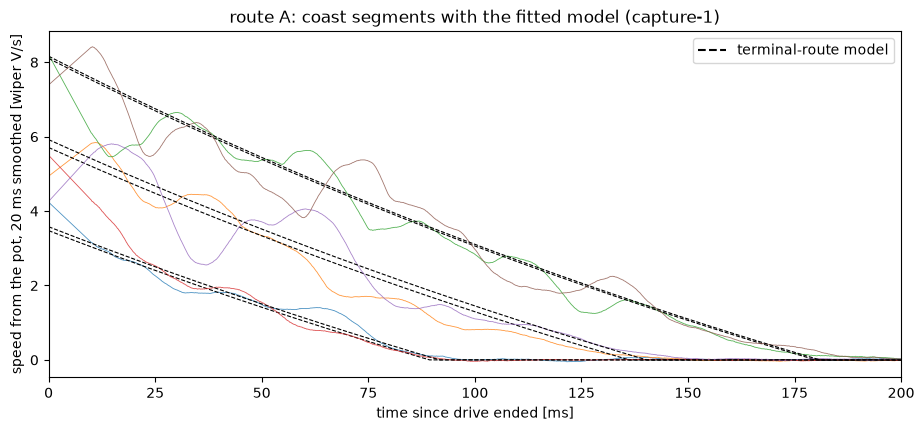

,EMF slope [V per wiper V/s],a [wiper V/s2],b [1/s],b se [1/s],a/b [wiper V/s],rms resid [mV],entry speed min [wiper V/s],entry speed max [wiper V/s]
mean,0.287,34.365,3.003,0.038,11.493,65.495,3.455,8.109
min,0.282,32.856,2.789,0.037,10.161,65.234,3.406,7.935
max,0.295,37.519,3.233,0.040,13.453,65.822,3.510,8.338


In [10]:
FIT_N = 5000    # 250 ms of every coast segment enters the fit
SG_WIN = 401    # 20 ms smoothing window for speed from the pot
COAST_SKIP = 3  # samples excluded at the start of every coast segment

spin_rails = {n: rail_V(df, 20, 40) for n, (df, _) in spin.items()}

def coast_segments(df):
    # Per coast segment: position and EMF vA - vB positive along the entry
    # direction, the terminal sum for the diode-phase mask, all in V.
    out = []
    for seg_id, seg in df[df["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb = seg["vb"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb)
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(df.loc[df["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "e": (vA - vB) * d,
            "sum": vA + vB,
        })
    return out

def coast_mask(c, rail):
    i = np.arange(len(c["e"]))
    return (i >= COAST_SKIP) & (c["sum"] < rail)

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def terminal_fit(segs, rail):
    # Shared (a, b) in EMF units, one entry value per segment.
    t = np.arange(FIT_N) / TICK_HZ
    masks = [coast_mask(c, rail)[:FIT_N] for c in segs]
    def resid(x):
        return np.concatenate([(speed_model(t, x[2 + i], x[0], x[1]) - c["e"][:FIT_N])[m]
                               for i, (c, m) in enumerate(zip(segs, masks))])
    x0 = [30.0, 5.0] + [max(c["e"][COAST_SKIP], 0.1) for c in segs]
    lb = [0.0, 0.0] + [0.0] * len(segs)
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    dof = len(res.fun) - len(res.x)
    cov = np.linalg.inv(res.jac.T @ res.jac) * np.sum(res.fun ** 2) / dof
    return {"a": res.x[0], "b": res.x[1], "b_se": np.sqrt(cov[1, 1]), "starts": res.x[2:],
            "rms_resid": np.sqrt(np.mean(res.fun ** 2))}

def terminal_slope(segs, rail):
    # EMF integral over the segment divided by the travel: V per wiper V/s.
    ratios = []
    for c in segs:
        m = coast_mask(c, rail)
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:COAST_SKIP])
        ratios.append(np.sum(c["e"][m]) / TICK_HZ / travel)
    return np.mean(ratios)

coast_fits = {}
for name, (df, _) in spin.items():
    segs = coast_segments(df)
    slope = terminal_slope(segs, spin_rails[name])
    f = terminal_fit(segs, spin_rails[name])
    coast_fits[name] = {"segs": segs, "slope": slope, "a": f["a"] / slope, "b": f["b"],
                        "b_se": f["b_se"], "starts": f["starts"] / slope,
                        "rms_resid": f["rms_resid"]}

fig, ax = plt.subplots(figsize=(11, 4.5))
name, f = next(iter(coast_fits.items()))
t = np.arange(FIT_N) / TICK_HZ
for i, c in enumerate(f["segs"]):
    v = savgol_filter(c["p"][:FIT_N], SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
    ax.plot(t * 1e3, v, lw=0.6, alpha=0.8)
    ax.plot(t * 1e3, speed_model(t, f["starts"][i], f["a"], f["b"]), "k--", lw=0.8)
ax.plot([], [], "k--", label="terminal-route model")
ax.set_xlim(0, 200)
ax.set_xlabel("time since drive ended [ms]")
ax.set_ylabel("speed from the pot, 20 ms smoothed [wiper V/s]")
ax.set_title(f"route A: coast segments with the fitted model ({name})")
ax.legend()
plt.show()

route_a = pd.DataFrame([{
    "recording": n, "EMF slope [V per wiper V/s]": f["slope"],
    "a [wiper V/s2]": f["a"], "b [1/s]": f["b"], "b se [1/s]": f["b_se"],
    "a/b [wiper V/s]": f["a"] / f["b"], "rms resid [mV]": f["rms_resid"] * 1e3,
    "entry speed min [wiper V/s]": f["starts"].min(), "entry speed max [wiper V/s]": f["starts"].max(),
} for n, f in coast_fits.items()]).set_index("recording")
route_a.agg(["mean", "min", "max"]).round(3)


In [11]:
# The same fit per direction, with the recording's EMF slope.
rows = []
for name, f in coast_fits.items():
    for d, label in [(1, "forward"), (-1, "reverse")]:
        segs = [c for c in f["segs"] if c["dir"] == d]
        ff = terminal_fit(segs, spin_rails[name])
        rows.append({"direction": label, "recording": name,
                     "a [wiper V/s2]": ff["a"] / f["slope"], "b [1/s]": ff["b"],
                     "a/b [wiper V/s]": ff["a"] / f["slope"] / ff["b"]})
route_a_dir = pd.DataFrame(rows).groupby("direction")[["a [wiper V/s2]", "b [1/s]", "a/b [wiper V/s]"]]
route_a_dir.agg(["mean", "min", "max"]).round(3)


a [wiper V/s2]                 b [1/s]                \
                    mean     min     max    mean    min    max   
direction                                                        
forward           35.453  33.644  39.134   2.875  2.666  3.179   
reverse           33.374  32.118  36.048   3.121  2.913  3.286   

          a/b [wiper V/s]                  
                     mean     min     max  
direction                                  
forward            12.413  10.584  14.677  
reverse            10.725   9.775  12.373

Findings:

- The EMF slope is 0.287 V per wiper V/s (0.282 to 0.295), the Coulomb
  term 34.4 wiper V/s$^2$ (32.9 to 37.5) and the viscous term 3.00 1/s
  (2.79 to 3.23), the values of notebook 01. The ratio $a / b$ is 11.5
  wiper V/s with a spread of 10.2 to 13.5 across the five recordings.
- Per direction, $a$ is 35.5 forward and 33.4 reverse and $b$ is 2.9 and
  3.1, an asymmetry of 6% in $a$ and 9% in $b$ of opposite sign, so the
  ratio is 12.4 forward and 10.7 reverse with overlapping spreads.
- The coast entry speeds are 3.4 to 8.3 wiper V/s, so route A is fitted
  below 8.5 wiper V/s and says nothing above it. The ratio $a / b$ lies
  above the fitted range, so at the top of the range the viscous term is
  seven tenths of the Coulomb term, and the split between the two rests on
  the curvature within the range.

## 7. Agreement of the two routes

The ratio $\tau_c / b_v$ is the speed at which viscous friction equals
Coulomb friction. Route A gives it as $a / b$ and route B as $i_c / i_v$,
with no inertia or torque constant involved. The table sets the two side
by side, route B in the matched speed range with the extrapolated steady
values (section 6.1), and the extended range and the reference-window
values for comparison.


In [12]:
ra = route_a["a/b [wiper V/s]"]
rows = [{"route": "A, coast", "direction": "both", "ratio [wiper V/s]": ra.mean(),
         "min": ra.min(), "max": ra.max(), "vs route A [%]": 0.0}]
for method, rname in [("extrapolated steady state", f"matched, <= {V_MATCH}"),
                      ("extrapolated steady state", f"extended, <= {V_EXT}"),
                      ("reference window, last 60%", f"matched, <= {V_MATCH}")]:
    for direction in ["forward", "reverse"]:
        f = route_b.loc[(method, rname, direction)]
        rows.append({"route": f"B, drive, {method}, {rname}", "direction": direction,
                     "ratio [wiper V/s]": f["ratio [wiper V/s]"], "min": f["ratio min"],
                     "max": f["ratio max"],
                     "vs route A [%]": (f["ratio [wiper V/s]"] / ra.mean() - 1) * 100})
agree = pd.DataFrame(rows).set_index(["route", "direction"])
agree.round(2)


ratio [wiper V/s]  \
route                                              direction                      
A, coast                                           both                   11.49   
B, drive, extrapolated steady state, matched, <... forward                 5.87   
                                                   reverse                 5.98   
B, drive, extrapolated steady state, extended, ... forward                 8.39   
                                                   reverse                 6.23   
B, drive, reference window, last 60%, matched, ... forward                 3.39   
                                                   reverse                 3.09   

                                                                min    max  \
route                                              direction                 
A, coast                                           both       10.16  13.45   
B, drive, extrapolated steady state, matched, <... forward     4.14   7.76   
                                                   reverse     3.93   8.11   
B, drive, extrapolated steady state, extended, ... forward     6.49   9.69   
                                                   reverse     5.06   7.66   
B, drive, reference window, last 60%, matched, ... forward     2.84   3.92   
                                                   reverse     2.12   4.29   

                                                              vs route A [%]  
route                                              direction                  
A, coast                                           both                 0.00  
B, drive, extrapolated steady state, matched, <... forward            -48.94  
                                                   reverse            -47.98  
B, drive, extrapolated steady state, extended, ... forward            -27.01  
                                                   reverse            -45.79  
B, drive, reference window, last 60%, matched, ... forward            -70.50  
                                                   reverse            -73.13

In [13]:
# The friction constants in both unit systems (route B in the matched range,
# extrapolated steady state).
fb = route_b.sort_index().loc[("extrapolated steady state", f"matched, <= {V_MATCH}")]
consts = pd.DataFrame([
    {"term": "Coulomb", "route A, mechanical": route_a["a [wiper V/s2]"].mean(), "unit A": "wiper V/s2",
     "route B forward": fb.loc["forward", "i_c [A]"], "route B reverse": fb.loc["reverse", "i_c [A]"], "unit B": "A"},
    {"term": "viscous", "route A, mechanical": route_a["b [1/s]"].mean(), "unit A": "1/s",
     "route B forward": fb.loc["forward", "i_v [A per wiper V/s]"], "route B reverse": fb.loc["reverse", "i_v [A per wiper V/s]"],
     "unit B": "A per wiper V/s"},
    {"term": "Coulomb / viscous", "route A, mechanical": ra.mean(), "unit A": "wiper V/s",
     "route B forward": fb.loc["forward", "ratio [wiper V/s]"], "route B reverse": fb.loc["reverse", "ratio [wiper V/s]"],
     "unit B": "wiper V/s"},
]).set_index("term")
# If one (tau_c, b_v) stood behind both routes, A / B would be Kt / J for both terms.
consts["A / B forward"] = consts["route A, mechanical"] / consts["route B forward"]
consts["A / B reverse"] = consts["route A, mechanical"] / consts["route B reverse"]
consts.round(4)


,"route A, mechanical",unit A,route B forward,route B reverse,unit B,A / B forward,A / B reverse
term,,,,,,,
Coulomb,34.3646,wiper V/s2,0.0388,0.0344,A,884.7263,998.1941
viscous,3.0030,1/s,0.0066,0.0058,A per wiper V/s,453.7273,521.5287
Coulomb / viscous,11.4929,wiper V/s,5.8687,5.9789,wiper V/s,1.9583,1.9222


Verdict:

- The two routes do not agree. Route A gives 11.5 wiper V/s with a spread
  of 10.2 to 13.5. Route B in the matched range gives 5.9 forward and 6.0
  reverse, 49% and 48% below route A, with per-recording spreads of 4.1 to
  7.8 and 3.9 to 8.1 that stop short of route A's lowest recording. The
  extended range brings the forward ratio to 8.4 (27% below) and leaves
  the reverse at 6.2. Both routes put the crossover speed within the
  range of speeds the mechanism reaches under drive, and both agree that
  Coulomb friction dominates below 6 wiper V/s. That is the extent of the
  agreement.
- Route B sees relatively more viscous friction than route A, by a factor
  of two. If the same $\tau_c$ and $b_v$ stood behind both, the ratios
  $a / i_c$ and $b / i_v$ would both equal $K_t / J$. They are 890 and
  450 wiper V/s$^2$ per A forward and 1000 and 520 reverse.
- Route A reproduces the stopping distances of notebook 01 within 7% at
  the higher entry speeds and the approach to rest of section 8.1 within
  3% by the EMF, so route A stands as the friction measurement of this
  notebook and route B is provisional.
- *Hypothesis (not tested here): the drive current at speed carries a term
  besides friction. Route B assumes the crest-scan sample is the
  period-average winding current and that the average current times a
  constant $K_t$ is the friction torque. At speed the drive current is the
  small difference between the applied voltage and the back-EMF, and any
  speed-dependent drop in the winding, the brushes or the switches that is
  absent at stall appears in it as a term proportional to speed, which is
  what raises $i_v$. Notebook 03 measures the back-EMF constant and the
  winding resistance from these same recordings and can predict the steady
  current at every grid point from speed alone. Where that prediction
  meets the measured current, route B can be read as friction.*
- *Hypothesis (not tested here): the route A split between $a$ and $b$ is
  biased by the EMF ripple. The ratio lies above the fitted speed range,
  so $b$ rests on the curvature of a decay that the 10% EMF ripple blurs.
  The standard error of 0.04 1/s on $b$ takes the residual as
  uncorrelated and understates this. A coast from above 12 wiper V/s
  would pin $b$ directly and needs a longer runway than the spin-down
  series has.*

## 8. Near rest and position dependence

### 8.1 The approach to rest

Notebook 01 found the model's stopping distance at the lowest coast
entry speed short of the measured one by 5% on average and asked whether
friction near rest falls below the fitted Coulomb term. The coast segments hold the answer in their
last tens of milliseconds, and two signals are available there, the pot
speed and the EMF. The pot ripple prevents a per-segment answer (a segment
covers a fraction of one ripple period in that window), so the thirty
coast segments are pooled. Each segment's rest instant is the first sample
after which the 20 ms smoothed pot speed stays below 0.1 wiper V/s (the
filter's half window at the segment end is excluded from the search), the
segments are aligned on that instant, and both speeds are averaged across
segments in 5 ms bins over the last 80 ms. The EMF is smoothed with the
same 20 ms window and converted with the recording's EMF slope. The
model's approach to rest under $(a, b)$ from section 6.2 is

$$v(t) = \frac{a}{b}\left(e^{-b\,(t - t_{rest})} - 1\right), \qquad t < t_{rest},$$

which is drawn over the pooled traces. The deceleration of each pooled
trace over two windows (45 to 15 ms and 25 to 5 ms before rest) is
compared with the model's over the same windows, and the pooled distance
to rest over the last 40 ms is fitted with a parabola, $d = a_{40}\,t^2 /
2$, for a third estimate that uses the position alone.


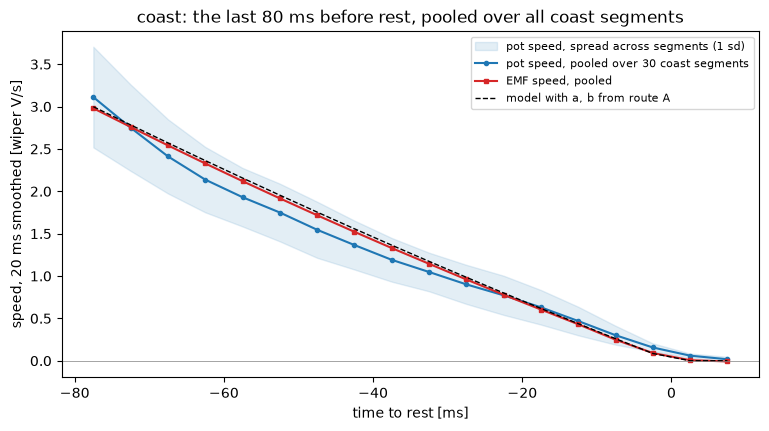

,v_pot,v_pot_sd,v_emf,v_emf_sd,dist_mV,v_pot_fwd,v_emf_fwd,v_pot_rev,v_emf_rev,v_model,dist_model_mV
bin center [ms to rest],,,,,,,,,,,
-77.5,3.112,0.594,2.980,0.212,105.156,2.855,3.000,3.369,2.959,2.999,111.696
-72.5,2.750,0.510,2.759,0.207,90.570,2.589,2.778,2.911,2.741,2.783,97.242
-67.5,2.412,0.438,2.542,0.197,77.670,2.327,2.556,2.498,2.528,2.571,83.856
-62.5,2.138,0.386,2.329,0.187,66.579,2.102,2.339,2.174,2.319,2.363,71.522
-57.5,1.930,0.345,2.120,0.177,56.498,1.980,2.125,1.880,2.115,2.157,60.225
-52.5,1.750,0.341,1.917,0.169,47.344,1.829,1.917,1.670,1.917,1.954,49.949
-47.5,1.546,0.331,1.718,0.163,38.904,1.621,1.713,1.471,1.722,1.754,40.679
-42.5,1.366,0.289,1.522,0.156,31.867,1.409,1.514,1.323,1.530,1.558,32.399
-37.5,1.191,0.258,1.330,0.148,25.468,1.217,1.318,1.166,1.342,1.364,25.096


In [14]:
A_COAST, B_COAST = route_a["a [wiper V/s2]"].mean(), route_a["b [1/s]"].mean()
REST_VPS = 0.1
HALF_WIN = SG_WIN // 2

traces = []
for name, f in coast_fits.items():
    for c in f["segs"]:
        p = c["p"]
        v = savgol_filter(p, SG_WIN, 2, deriv=1, delta=1 / TICK_HZ)
        e = np.where(coast_mask(c, spin_rails[name]), c["e"], 0.0)
        ve = savgol_filter(e, SG_WIN, 2) / f["slope"]
        t_rest = np.where(v[:-HALF_WIN] > REST_VPS)[0][-1] + 1
        p_rest = np.median(p[-1000:])
        tt = (np.arange(len(p)) - t_rest) / TICK_HZ * 1e3
        traces.append(pd.DataFrame({"dir": c["dir"], "t_ms": tt, "v_pot": v, "v_emf": ve,
                                    "dist": p_rest - p}))
tr = pd.concat(traces)
tr = tr[(tr["t_ms"] >= -80) & (tr["t_ms"] < 10)].copy()
tr["bin_ms"] = (tr["t_ms"] // 5) * 5
pooled = tr.groupby("bin_ms").agg(v_pot=("v_pot", "mean"), v_pot_sd=("v_pot", "std"),
                                  v_emf=("v_emf", "mean"), v_emf_sd=("v_emf", "std"),
                                  dist_mV=("dist", "mean"))
pooled["dist_mV"] *= 1e3
for d, label in [(1, "fwd"), (-1, "rev")]:
    g = tr[tr["dir"] == d].groupby("bin_ms")
    pooled[f"v_pot_{label}"] = g["v_pot"].mean()
    pooled[f"v_emf_{label}"] = g["v_emf"].mean()
tm = pooled.index.to_numpy() + 2.5
tp = np.maximum(-tm, 0) / 1e3     # time to rest, s
pooled["v_model"] = A_COAST / B_COAST * (np.exp(B_COAST * tp) - 1)
pooled["dist_model_mV"] = (A_COAST / B_COAST ** 2 * (np.exp(B_COAST * tp) - 1) - A_COAST / B_COAST * tp) * 1e3
pooled.index = tm
pooled.index.name = "bin center [ms to rest]"

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.fill_between(tm, pooled["v_pot"] - pooled["v_pot_sd"], pooled["v_pot"] + pooled["v_pot_sd"],
                color="tab:blue", alpha=0.12, label="pot speed, spread across segments (1 sd)")
ax.plot(tm, pooled["v_pot"], "-o", ms=3, color="tab:blue", label="pot speed, pooled over 30 coast segments")
ax.plot(tm, pooled["v_emf"], "-s", ms=3, color="tab:red", label="EMF speed, pooled")
ax.plot(tm, pooled["v_model"], "k--", lw=1, label="model with a, b from route A")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("time to rest [ms]")
ax.set_ylabel("speed, 20 ms smoothed [wiper V/s]")
ax.set_title("coast: the last 80 ms before rest, pooled over all coast segments")
ax.legend(fontsize=8)
plt.show()

pooled.round(3)


In [15]:
def decel(series, lo, hi):
    m = (series.index >= lo) & (series.index <= hi)
    return -np.polyfit(series.index[m] / 1e3, series[m], 1)[0]

def parabola_a(series, lo):
    m = (series.index >= lo) & (series.index < 0)
    t2 = (series.index[m] / 1e3) ** 2
    return 2 * np.polyfit(t2, series[m] / 1e3, 1)[0]

rows = []
for lo, hi in [(-45, -15), (-25, -5)]:
    rows.append({"quantity": f"deceleration, {-lo} to {-hi} ms before rest [wiper V/s2]",
                 "pot, pooled": decel(pooled["v_pot"], lo, hi),
                 "pot, forward": decel(pooled["v_pot_fwd"], lo, hi),
                 "pot, reverse": decel(pooled["v_pot_rev"], lo, hi),
                 "EMF, pooled": decel(pooled["v_emf"], lo, hi),
                 "EMF, forward": decel(pooled["v_emf_fwd"], lo, hi),
                 "EMF, reverse": decel(pooled["v_emf_rev"], lo, hi),
                 "model": decel(pooled["v_model"], lo, hi)})
rows.append({"quantity": "parabola a over the last 40 ms of distance to rest [wiper V/s2]",
             "pot, pooled": parabola_a(pooled["dist_mV"], -40),
             "model": parabola_a(pooled["dist_model_mV"], -40)})
rows.append({"quantity": "Coulomb term a from route A [wiper V/s2]", "model": A_COAST})
near_tab = pd.DataFrame(rows).set_index("quantity").round(1)
near_tab


,"pot, pooled","pot, forward","pot, reverse","EMF, pooled","EMF, forward","EMF, reverse",model
quantity,,,,,,,
"deceleration, 45 to 15 ms before rest [wiper V/s2]",29.0,29.8,28.2,36.7,37.8,35.7,37.6
"deceleration, 25 to 5 ms before rest [wiper V/s2]",31.5,34.6,28.4,35.3,35.1,35.5,36.0
parabola a over the last 40 ms of distance to rest [wiper V/s2],34.1,NaN,NaN,NaN,NaN,NaN,35.7
Coulomb term a from route A [wiper V/s2],NaN,NaN,NaN,NaN,NaN,NaN,34.4


Findings:

- By the EMF the pooled speed follows the route A model to within 3% at
  every 5 ms bin from 80 ms to 10 ms before rest, and the two directions
  straddle it by up to 9% in the last 20 ms, where the alignment on the
  pot's rest instant is uncertain by a few milliseconds. The EMF
  deceleration is 36.7 wiper V/s$^2$ over 45 to 15 ms before rest and
  35.3 over 25 to 5 ms, against the model's 37.6 and 36.0. There is no plateau before rest and no abrupt stop from a
  finite speed, so the mechanism glides to rest under the same Coulomb
  term the fit found at speed, and no separate near-rest term is needed.
- By the pot the pooled speed runs 9 to 13% below the model between 60
  and 30 ms before rest and its deceleration over 45 to 15 ms is 29, with
  the two directions at 30 and 28. The pooled distance to rest over the last
  40 ms gives a Coulomb term of 34 against the model's 36, so the position
  itself agrees with the model and the shortfall sits in the pot-derived
  speed. *Hypothesis (not tested here): the pot ripple does not average
  out in this pool, since every coast of a given entry duty comes to rest
  near the same position and the ripple phases across recordings are
  therefore correlated, which the spread of the forward and reverse pot
  traces against the EMF traces supports.*
- Notebook 01's low-speed stopping-distance shortfall is therefore not
  from the approach to rest. The friction in the last 80 ms is the fitted
  friction.

### 8.2 Position dependence

The matched-range grid steps end at 0.7 to 1.0 wiper V forward and 2.2
to 2.5 wiper V reverse. The figure plots the residual of every
matched-range route B step from its direction's line (section 6.1)
against the step's position, and the table bins it by position and by
duty. One limit needs stating first. Every step of a given duty starts
from the same repositioned end and reaches the same position, so
position, duty, speed and time into the sweep are confounded by design. A
residual that varies with position cannot be separated from a departure
of the current from the linear speed model. The bins are shown for what
they are.


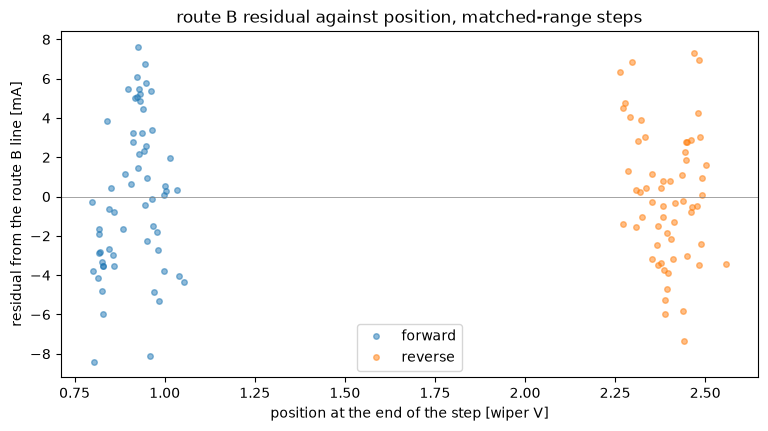

residual_mA  sd_mA  steps  duty_pct  \
direction position bin [wiper V]                                        
forward   0.7                           -0.29    NaN      1     15.00   
          0.8                           -2.19   3.03     22     18.64   
          0.9                            1.68   3.91     32     32.03   
          1.0                           -0.88   2.65      6     40.83   
reverse   2.2                            3.77   2.91      7     40.00   
          2.3                           -1.22   2.60     25     32.80   
          2.4                            0.23   3.44     26     20.00   
          2.5                           -0.92   3.56      2     15.00   

                                  speed_Vps  
direction position bin [wiper V]             
forward   0.7                          2.44  
          0.8                          3.56  
          0.9                          5.71  
          1.0                          7.63  
reverse   2.2                          8.18  
          2.3                          6.63  
          2.4                          3.68  
          2.5                          3.35

In [16]:
rows = []
for d, label in [(1, "forward"), (-1, "reverse")]:
    f = route_b.loc[("extrapolated steady state", f"matched, <= {V_MATCH}", label)]
    g = grid_tab[(grid_tab["dir"] == d) & (grid_tab["v_ss_Vps"] <= V_MATCH)].copy()
    g["residual_mA"] = (g["i_ss_A"] - f["i_c [A]"] - f["i_v [A per wiper V/s]"] * g["v_ss_Vps"]) * 1e3
    g["direction"] = label
    rows.append(g)
res = pd.concat(rows)
res["position bin [wiper V]"] = (res["pos_V"] // 0.1) * 0.1

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, color in [("forward", "tab:blue"), ("reverse", "tab:orange")]:
    g = res[res["direction"] == label]
    ax.plot(g["pos_V"], g["residual_mA"], "o", ms=4, alpha=0.5, color=color, label=label)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("position at the end of the step [wiper V]")
ax.set_ylabel("residual from the route B line [mA]")
ax.set_title("route B residual against position, matched-range steps")
ax.legend()
plt.show()

by_pos = (res.groupby(["direction", "position bin [wiper V]"])
          .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
               steps=("residual_mA", "size"), duty_pct=("mag_pct", "mean"), speed_Vps=("v_ss_Vps", "mean")))
by_pos.round(2)


In [17]:
# The same residuals binned by duty, which is the other axis of the confound.
(res.groupby(["direction", "mag_pct"])
    .agg(residual_mA=("residual_mA", "mean"), sd_mA=("residual_mA", "std"),
         steps=("residual_mA", "size"), speed_Vps=("v_ss_Vps", "mean"))
    .round(2))


residual_mA  sd_mA  steps  speed_Vps
direction mag_pct                                      
forward   15             -3.42   2.19     10       2.70
          20             -2.19   2.17     10       3.97
          25              4.04   2.76     10       4.31
          30              3.97   1.71     10       5.15
          35              0.09   2.92     10       6.37
          40             -2.06   3.30     10       7.57
          45             -4.35    NaN      1       8.48
reverse   15              2.31   3.33     10       2.88
          20              0.34   2.19     10       3.51
          25             -2.89   2.51     10       4.82
          30             -2.72   1.92     10       6.00
          35             -0.22   2.09     10       7.11
          40              3.18   2.91     10       8.21

Findings:

- The binned residuals lie within 4 mA of zero in both directions, with a
  scatter of 3 to 4 mA within each bin, against a steady current of 50 to
  90 mA. No position bin stands out of the scatter.
- Binned by duty the residuals show a small curvature, concave forward
  (negative at 15% and 20%, positive at 25% and 30%) and convex reverse
  (the opposite signs at the same points), at the 3 to 4 mA level, which
  is 4 to 8% of the current. Since each duty is one position, the same
  pattern reads as a position effect of opposite sign in the two
  directions, and the design cannot tell the two apart.
- Within the matched range friction shows no position dependence that this
  design can resolve above the 5% level. A test that separates position
  from speed needs steps of one duty started from several positions, which
  none of the three series provides.

## 9. Limitations and open issues

- **One unit, one supply.** All numbers describe this one servo on a
  2-cell battery that was not recharged between recordings. The gear
  train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per recording and removes itself from the EMF.
- **The ramp has a 1% grid and five recordings.** The breakaway band is
  one to two grid steps wide and the 5% step is marginal in both
  directions, so the direction asymmetry is unresolved.
- **The breakaway current is model-derived** from notebook 03's
  resistance (section 5.3). The ramp's own current channel is unsettled
  throughout.
- **The grid steps are short.** The steady current and speed are
  extrapolated with a fitted exponential (section 6.1). From 50% duty
  up the transient left in the reference window exceeds 45% of the
  extrapolated value, and the fall of the extrapolated current above
  12 wiper V/s may be the extrapolation's own artifact.
- **Route B is provisional.** The two routes disagree by a factor of two
  in the ratio of Coulomb to viscous friction (section 7). The electrical
  model of notebook 03 is needed before route B can be read as friction.
- **Route A's split is range-limited.** The coast entries reach
  8.3 wiper V/s and the fitted crossover lies at 11.5, so $b$ rests on
  the curvature within the range and the EMF ripple limits it.
- **The pot ripple** limits every per-segment or per-step speed estimate
  to about 30% at low speed, and it does not average out of a pool whose
  segments rest at correlated positions (section 8.1). The EMF and the
  extrapolated estimates avoid it, the per-step pot estimates do not.
- **Position, speed and duty are confounded** in the grid (section 8.2).

## 10. What the next notebooks use from here

- The breakaway band of 0.37 to 0.51 V forward and 0.37 to 0.44 V
  reverse (section 5.2), as the dead zone any open-loop voltage command
  has to cross, and the model-derived breakaway current of 0.085 to
  0.12 A with notebook 03's 4.3 Ohm.
- The friction constants of route A, Coulomb 34.4 wiper V/s$^2$ and
  viscous 3.00 1/s with a crossover at 11.5 wiper V/s (section 6.2), as
  the friction terms of the plant model. The approach to rest follows
  them with no separate near-rest term (section 8.1).
- The route B lines of section 6.1, $i_c$ of 0.039 and 0.034 A and $i_v$
  of 0.0066 and 0.0058 A per wiper V/s forward and reverse, as the
  measured steady current at every grid point in the matched range, for
  notebook 03 to compare with its prediction from speed, resistance and
  back-EMF constant. The difference is the term of the drive current that
  this notebook could not separate from friction.
- The drive time constant of 17 to 21 ms (section 6.1), which the inertia
  notebook combines with the coast damping of 3.0 1/s and the brake
  damping of notebook 01 to separate inertia from the electrical damping.
- The EMF as the near-rest speed signal of choice, since the pooled pot
  speed carries a correlated ripple residue that the EMF does not
  (section 8.1).
- The fact that the grid confounds position with speed, so that a
  position-dependence test needs a dedicated series.
